# **🔋Time-Series Forecasting of Household Energy Consumption**

This project focuses on forecasting household energy consumption using classical, machine learning, and deep learning approaches. The objective is to compare the performance of ARIMA, Random Forest, and LSTM models in predicting energy usage patterns based on historical data.

Key steps include:

- Data preprocessing and cleaning
- Feature engineering
- Model development
- Performance evaluation


# **📊 Dataset Description**

The dataset used in this study is the "Individual Household Electric Power Consumption" dataset.

It contains over 2 million records of minute-level measurements including:
- Global active power
- Voltage
- Sub-metering values

Due to its high frequency and real-world nature, the dataset presents challenges such as missing values and noise.

In [ ]:
pip install ucimlrepo

In [ ]:
#Libraries
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.preprocessing import MinMaxScaler

In [ ]:
#Fetching and Loading Dataset
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=235)
df = dataset.data.features.copy()

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [ ]:
#Initial Check
print(df.head())
print(df.info())

         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column      

## 🧹 Data Preprocessing

The dataset initially contained missing values (approximately 25,979 entries).

To handle this, forward-fill imputation was applied to maintain temporal consistency.

Additionally:
- Date and Time columns were combined into a single datetime index
- All columns were converted into numeric format for modeling

This step ensures the dataset is clean and suitable for time-series analysis.

In [ ]:
#Handling Missing Values
print("Missing before:", df.isnull().sum().sum())
df.fillna(method='ffill', inplace=True)
print("Missing after:", df.isnull().sum().sum())

Missing before: 25979
Missing after: 0


In [ ]:
#Combining Date & Time
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)
print(df.columns)

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'datetime'],
      dtype='object')


In [ ]:
#Setting index
df.set_index('datetime', inplace=True)

In [ ]:
#Dropping original columns
if 'Date' in df.columns and 'Time' in df.columns:
    df.drop(['Date', 'Time'], axis=1, inplace=True)

In [ ]:
# Converting columns into numeric
df = df.apply(pd.to_numeric, errors='coerce')

## ⏱️ Data Resampling

Since the dataset is recorded at a minute-level frequency, it was resampled into hourly intervals.

This was done to:
- Reduce noise
- Improve computational efficiency
- Capture broader temporal trends

Hourly aggregation was performed using mean values.

In [ ]:
# Resampling
df_hourly = df.resample('h').mean()
print(df_hourly.head())

                     Global_active_power  Global_reactive_power     Voltage  \
datetime                                                                      
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2006-12-16 19:00:00             3.400233               0.085233  233.232500   
2006-12-16 20:00:00             3.268567               0.075100  234.071500   
2006-12-16 21:00:00             3.056467               0.076667  237.158667   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
datetime                                                                
2006-12-16 17:00:00         18.100000             0.0        0.527778   
2006-12-16 18:00:00         15.600000             0.0        6.716667   
2006-12-16 19:00:00         14.503333             0.0        1.433333   
2006-12-16 20:00:00         13.916667             0.0        0.000000   
2006-12-

## ⚙️ Feature Engineering

To improve model performance, several features were engineered:

### Time-Based Features
- Hour of the day
- Day of the month
- Month

### Cyclical Encoding
- Sine and cosine transformations of hours were used to capture periodic patterns


In [ ]:
# Time-based features
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day'] = df_hourly.index.day
df_hourly['month'] = df_hourly.index.month

# Cyclical encoding
df_hourly['sin_hour'] = np.sin(2 * np.pi * df_hourly.index.hour / 24)
df_hourly['cos_hour'] = np.cos(2 * np.pi * df_hourly.index.hour / 24)

### Lag Features
- Previous 1, 2, 24, and 168 hours of energy consumption


In [ ]:
# Lag Features

# Lag of 1 hour
df_hourly['lag_1'] = df_hourly['Global_active_power'].shift(1)

# Lag of 2 hours
df_hourly['lag_2'] = df_hourly['Global_active_power'].shift(2)

# Lag of 24 hours (same hour previous day)
df_hourly['lag_24'] = df_hourly['Global_active_power'].shift(24)

# Lag of 168 hours (same hour previous week)
df_hourly['lag_168'] = df_hourly['Global_active_power'].shift(168)

### Rolling Statistics
- Moving averages over 3, 6, and 24-hour windows

These features help models learn temporal dependencies and seasonal patterns.

In [ ]:
# Rolling Statistics

# Rolling mean (3-hour window)
df_hourly['rolling_mean_3'] = df_hourly['Global_active_power'].rolling(window=3).mean()

# Rolling mean (6-hour window)
df_hourly['rolling_mean_6'] = df_hourly['Global_active_power'].rolling(window=6).mean()

# Rolling mean (24-hour window)
df_hourly['rolling_mean_24'] = df_hourly['Global_active_power'].rolling(window=24).mean()


In [ ]:
# Handle NaN from Feature Creation

df_hourly.dropna(inplace=True)
print(df_hourly.head())

                     Global_active_power  Global_reactive_power     Voltage  \
datetime                                                                      
2006-12-23 17:00:00             5.452533               0.215967  233.644167   
2006-12-23 18:00:00             3.879400               0.099767  238.000500   
2006-12-23 19:00:00             4.117833               0.205333  238.729333   
2006-12-23 20:00:00             4.181400               0.124767  238.518833   
2006-12-23 21:00:00             3.288433               0.235767  238.594667   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
datetime                                                                
2006-12-23 17:00:00         23.360000       16.183333        0.666667   
2006-12-23 18:00:00         16.363333        0.000000        0.016667   
2006-12-23 19:00:00         17.300000        0.000000        0.600000   
2006-12-23 20:00:00         17.596667        0.000000        0.350000   
2006-12-

## 🔀 Train-Test Split and Scaling

The dataset was split chronologically:
- 80% for training
- 20% for testing


In [ ]:
# Defining Target & Features

target = 'Global_active_power'

X = df_hourly.drop(columns=[target])
y = df_hourly[target]

In [ ]:
# Train-Test Split (Time-based)

split_ratio = 0.8
split_index = int(len(df_hourly) * split_ratio)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

Min-Max scaling was applied to normalize the data, which is particularly important for machine learning and deep learning models.

In [ ]:
# Scaling

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fitting only on training data
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (26709, 18)
Test shape: (6678, 18)


# **Models**

## 📉 ARIMA Model (Baseline)

A classical ARIMA model was implemented as a baseline approach.

This model assumes linear relationships and works best with stationary data.

### Results:
- MAE: 0.77
- RMSE: 0.89
- R²: -0.42

The poor performance suggests that the dataset contains nonlinear patterns that ARIMA fails to capture.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Useing y_train and y_test (NOT scaled)
train = y_train.copy()
test = y_test.copy()


In [ ]:
# ARIMA Model
model = ARIMA(train, order=(1,1,1),
              enforce_stationarity=False,
              enforce_invertibility=False)

model_fit = model.fit(method_kwargs={"maxiter": 200})

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
# Forecasting for test period
predictions = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [ ]:
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
r2 = r2_score(test, predictions)

print("ARIMA Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

ARIMA Performance:
MAE: 0.7742793138967837
RMSE: 0.8980981946607346
R2: -0.4240180561906588


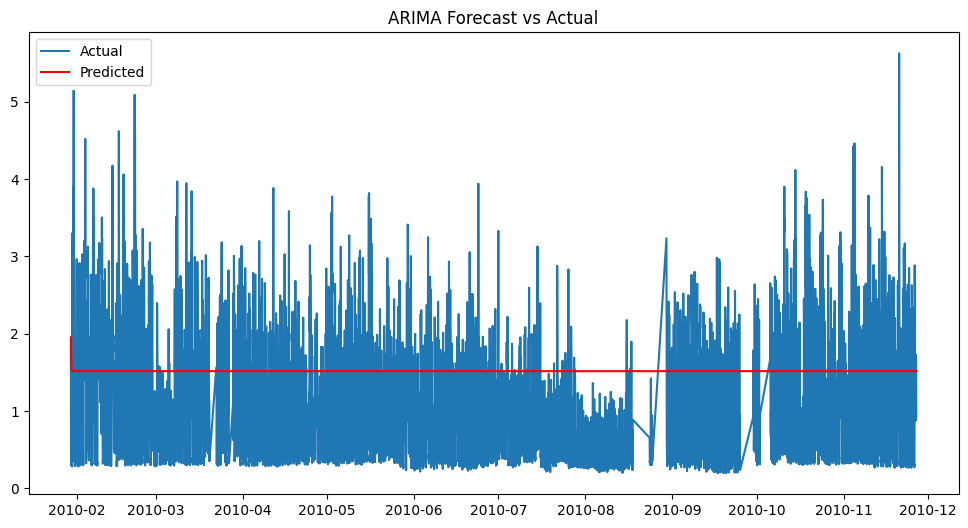

In [ ]:
import matplotlib.pyplot as plt

# Align index
predictions.index = test.index

plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual')
plt.plot(predictions.index, predictions, label='Predicted', color='red')
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

## 🌲 Random Forest Model

A Random Forest Regressor was used to capture nonlinear relationships in the data.

This model leverages multiple decision trees to improve prediction accuracy.

### Results:
- MAE: 0.012
- RMSE: 0.021
- R²: 0.999

The model achieved excellent performance, indicating that feature engineering significantly improved predictive capability.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
#Using Scaled Data
X_train_scaled, X_test_scaled
y_train_scaled, y_test_scaled

(array([[0.82785765],
        [0.58345072],
        [0.62049447],
        ...,
        [0.22288913],
        [0.23373348],
        [0.3155736 ]]),
 array([[0.26287443],
        [0.04983532],
        [0.0472045 ],
        ...,
        [0.2385342 ],
        [0.16153105],
        [0.12594772]]))

In [ ]:
#Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train_scaled.ravel())

RandomForestRegressor(n_jobs=-1, random_state=42)

In [ ]:
#Predictions
rf_predictions_scaled = rf_model.predict(X_test_scaled)

In [ ]:
#Converting Back to Original Scale
rf_predictions = scaler_y.inverse_transform(rf_predictions_scaled.reshape(-1,1))
y_test_actual = scaler_y.inverse_transform(y_test_scaled)

In [ ]:
#Evaluation
mae = mean_absolute_error(y_test_actual, rf_predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, rf_predictions))
r2 = r2_score(y_test_actual, rf_predictions)

print("Random Forest Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Random Forest Performance:
MAE: 0.012864022909640291
RMSE: 0.021003672010225315
R2: 0.9992211419644481


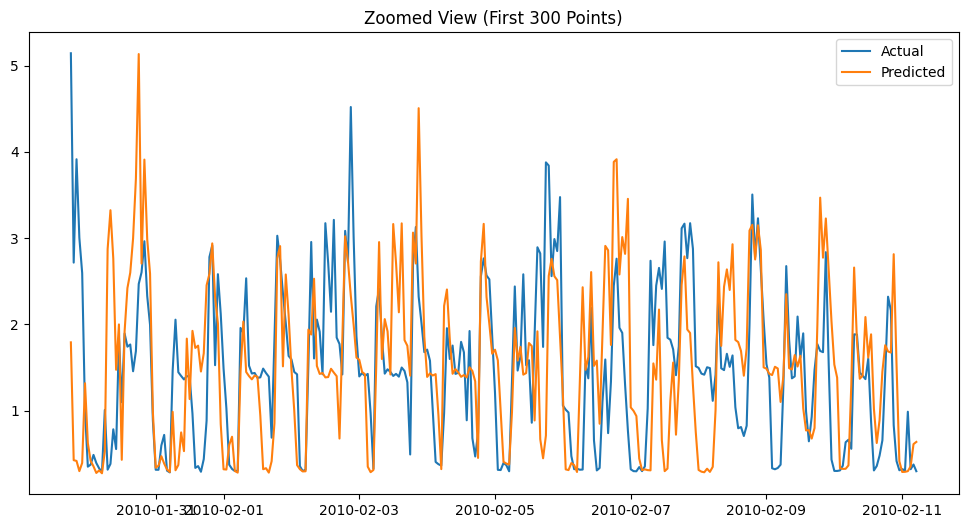

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index[:300], y_test_actual[:300], label='Actual')
plt.plot(y_test.index[:300], rf_predictions[:300], label='Predicted')

plt.legend()
plt.title("Zoomed View (First 300 Points)")
plt.show()

## 🧠 LSTM Model (Deep Learning)

An LSTM model was implemented to capture temporal dependencies in the data.

Sequences of 24 hours were used as input to predict future values.

### Results:
- MAE: 0.336
- RMSE: 0.483
- R²: 0.584

While LSTM captured temporal patterns, its performance was lower than Random Forest, possibly due to model complexity and tuning challenges.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
#Creating Sequences and applying it to data
def create_sequences(X, y, time_steps=24):
    Xs, ys = [], []

    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])

    return np.array(Xs), np.array(ys)

time_steps = 24  # past 24 hours

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)

print(X_train_seq.shape)

(26685, 24, 18)


In [ ]:
#LSTM Model
from tensorflow.keras.layers import Input

model = Sequential()

model.add(Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(1))

In [ ]:
#Compileing
model.compile(optimizer='adam', loss='mse')

In [ ]:
#Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
#Model Training

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0130 - val_loss: 0.0102
Epoch 2/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0093 - val_loss: 0.0091
Epoch 3/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0085 - val_loss: 0.0085
Epoch 4/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0081 - val_loss: 0.0082
Epoch 5/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0080 - val_loss: 0.0083
Epoch 6/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0078 - val_loss: 0.0087
Epoch 7/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0076 - val_loss: 0.0079
Epoch 8/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0076 - val_loss: 0.0078
Epoch 9/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0075 - val_loss: 0.0083
Epoch 10/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0074 - val_loss: 0.0075
Epoch 11/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0074 - val_loss: 0.0078
Epoch 12/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
#Predictions
lstm_predictions_scaled = model.predict(X_test_seq)

208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
#Inverse Transform
lstm_predictions = scaler_y.inverse_transform(lstm_predictions_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

In [ ]:
#Eveluation
mae = mean_absolute_error(y_test_actual, lstm_predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))
r2 = r2_score(y_test_actual, lstm_predictions)

print("LSTM Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

LSTM Performance:
MAE: 0.33657325876964084
RMSE: 0.4838254848935425
R2: 0.5845783541543055


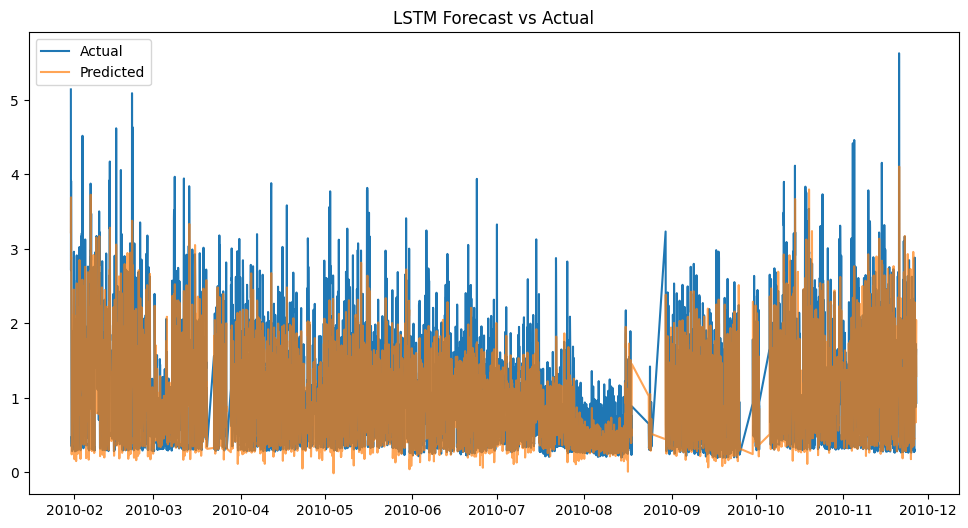

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.index[24:], y_test_actual, label='Actual')
plt.plot(y_test.index[24:], lstm_predictions, label='Predicted', alpha=0.7)

plt.legend()
plt.title("LSTM Forecast vs Actual")
plt.show()

In [ ]:
# Storing results
results = pd.DataFrame({
    'Model': ['ARIMA', 'Random Forest', 'LSTM'],
    'MAE': [0.7743, 0.0129, 0.3366],
    'RMSE': [0.8981, 0.0210, 0.4838],
    'R2': [-0.4240, 0.9992, 0.5846]
})

results

,Model,MAE,RMSE,R2
0,ARIMA,0.7743,0.8981,-0.4240
1,Random Forest,0.0129,0.0210,0.9992
2,LSTM,0.3366,0.4838,0.5846


## 📊 Model Comparison

| Model | MAE | RMSE | R² |
|------|-----|------|-----|
| ARIMA | 0.77 | 0.89 | -0.42 |
| Random Forest | 0.012 | 0.021 | 0.999 |
| LSTM | 0.336 | 0.483 | 0.584 |

## ✅ Conclusion

Among the models evaluated, the Random Forest model performed the best, achieving the highest accuracy.

This suggests that:
- Feature engineering plays a crucial role
- Nonlinear models are more suitable for this dataset

The ARIMA model struggled due to its linear assumptions, while the LSTM model showed moderate performance but requires further tuning.

Future work could include hybrid models and incorporation of external factors such as weather data.